In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
train_frac = 0.2
val_frac = 0.001
dataset = WaveletDataset(root="/home/hice1/mchen439/scratch/eegfoundationmodeldata", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 2651 subjects


100%|██████████| 2651/2651 [01:07<00:00, 39.54it/s]

Train and Validation Dataset Length:  25436 128


In [3]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


In [4]:
train_loader = DataLoader(train_dataset, batch_size=128, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, num_workers=2, shuffle=False)
print(len(train_loader), len(val_loader))

199 1


In [5]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [12]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, seq_len, heads, encoder_conv_kernel_size, encoder_conv_kernel_stride, encoded_h, device):
        super(WaveletEncoderDecoder, self).__init__()
        self.num_channels = num_channels

        self.seq_len = seq_len
        self.heads = heads
        self.encoded_h = encoded_h
        self.device = device
        self.conv_kernel_size = encoder_conv_kernel_size
        self.conv_kernel_stride = encoder_conv_kernel_stride

        L_out = self.seq_len + 2 * (self.conv_kernel_size//2) - 1 * (self.conv_kernel_size - 1) - 1
        L_out = floor(L_out / self.conv_kernel_stride) + 1

        self.window_embedder = nn.Sequential(
            nn.Dropout1d(0.1),
            nn.Conv1d(self.num_channels, self.num_channels, 
            self.conv_kernel_size, stride=self.conv_kernel_stride,
            padding=self.conv_kernel_size//2),
            nn.BatchNorm1d(self.num_channels), # Same as Layer Norm
            nn.GELU(),
            nn.Linear(L_out, self.encoded_h)
        ).to(self.device)

        #self.gnn_encoder = GATConv(self.encoded_h, self.encoded_h, heads=self.heads, concat=False).to(self.device)
        self.gnn_encoder = SplineConv(self.encoded_h, self.encoded_h, dim=1, kernel_size=3).to(self.device)

        #self.gnn_bnorm = nn.BatchNorm1d(self.num_channels)
        #self.dropout = nn.Dropout1d(0.1)
        self.act = nn.GELU()
        #self.lin = nn.Linear(self.encoded_h, self.encoded_h)

        self.learnable_padding = torch.nn.Parameter(torch.normal(0, self.encoded_h**(-0.5), size=(self.num_channels, self.seq_len - self.encoded_h), requires_grad=True))
        self.transformer_decoder1 = nn.TransformerDecoderLayer(self.num_channels, nhead=1, dim_feedforward=L_out, activation=nn.GELU(), batch_first=True).to(self.device)
        self.transformer_decoder2 = nn.TransformerDecoderLayer(self.num_channels, nhead=1, dim_feedforward=L_out, activation=nn.GELU(), batch_first=True).to(self.device)

    def getEncoderParamCount(self):
        gnn_encoder_count = sum(p.numel() for p in self.gnn_encoder.parameters() if p.requires_grad)
        return gnn_encoder_count

    def getDecoderParamCount(self):
        transformer_decoder1_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        transformer_decoder2_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        return transformer_decoder1_count + transformer_decoder2_count

    def forward(self, graph, x):
        patch_embedding = self.act(self.window_embedder(x))
        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)
        gnn_encoder_input = patch_embedding.view(-1, patch_embedding.shape[-1])
        encoding = self.gnn_encoder(gnn_encoder_input, edge_index, edge_dist)
        encoding = encoding.view(-1, self.num_channels, self.encoded_h)
        #encoding = self.gnn_bnorm(encoding)
        #encoding = self.dropout(encoding)
        #encoding = self.lin(encoding)

        decoding_tgt = torch.cat([encoding, self.learnable_padding.repeat((x.shape[0], 1, 1))], dim=-1).to(encoding.device)
        decoding = self.transformer_decoder1(tgt=decoding_tgt.permute([0, 2, 1]), memory=encoding.permute([0, 2, 1]))
        # Skip Connnection
        decoding = decoding.permute([0, 2, 1]) + decoding_tgt
        decoding_skip = self.transformer_decoder2(tgt=decoding.permute([0, 2, 1]), memory=encoding.permute([0, 2, 1]))
        # Skip Connnection
        decoding = decoding_skip.permute([0, 2, 1]) + decoding
        return encoding, decoding


'''
Initialize Encoders for each wavelet band and 
put them into a single object.
'''
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    seq_len = 246,
                    heads = 1,
                    encoded_h = 124,
                    encoder_conv_kernel_size = 2,
                    encoder_conv_kernel_stride = 2,
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    seq_len = 246,
                    heads = 1,
                    encoded_h = 124,
                    encoder_conv_kernel_size = 2,
                    encoder_conv_kernel_stride = 2,
                    device = device
                    ),
            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    seq_len = 486,
                    heads = 1,
                    encoded_h = 244,
                    encoder_conv_kernel_size = 2,
                    encoder_conv_kernel_stride = 2,
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    seq_len = 966,
                    heads = 1,
                    encoded_h = 484,
                    encoder_conv_kernel_size = 2,
                    encoder_conv_kernel_stride = 2,
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    seq_len = 1925,
                    heads = 1,
                    encoded_h = 246,
                    encoder_conv_kernel_size = 4,
                    encoder_conv_kernel_stride = 4,
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output

    def freeze_features(self, unfreeze=False, finetuning=False):
        for param in self.parameters():
            param.requires_grad = unfreeze
        if finetuning:
            self.mask_replacement.requires_grad = False

In [13]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

In [14]:
model = EncoderDecoder(device).to(device)
optimizer = MixOptimizer(torch.optim.Adam(model.parameters(), lr=1e-3))
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Total parameters: 2186164


In [15]:
print(model.encoder_decoders['delta'].getEncoderParamCount())
print(model.encoder_decoders['delta'].getDecoderParamCount())
print(model.encoder_decoders['theta'].getEncoderParamCount())
print(model.encoder_decoders['theta'].getDecoderParamCount())
print(model.encoder_decoders['alpha'].getEncoderParamCount())
print(model.encoder_decoders['alpha'].getDecoderParamCount())
print(model.encoder_decoders['beta'].getEncoderParamCount())
print(model.encoder_decoders['beta'].getDecoderParamCount())
print(model.encoder_decoders['gamma'].getEncoderParamCount())
print(model.encoder_decoders['gamma'].getDecoderParamCount())

61628
16018
61628
16018
238388
25378
937508
44098
242310
43942


In [16]:
def fft_loss(output, target):
    output_fft = torch.fft.fft(output, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle))) * 1e-1

In [17]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = loss_fn(inputs['delta'], outputs['delta'][1]) + fft_loss(inputs['delta'], outputs['delta'][1]) 
		theta_loss = loss_fn(inputs['theta'], outputs['theta'][1])  + fft_loss(inputs['theta'], outputs['theta'][1])
		alpha_loss = loss_fn(inputs['alpha'], outputs['alpha'][1])  + fft_loss(inputs['alpha'], outputs['alpha'][1])
		beta_loss =  loss_fn(inputs['beta'],  outputs['beta'][1])  + fft_loss(inputs['beta'], outputs['beta'][1])
		gamma_loss = loss_fn(inputs['gamma'], outputs['gamma'][1])  + fft_loss(inputs['gamma'], outputs['gamma'][1])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [18]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = loss_fn(inputs['delta'], outputs['delta'][1]) + fft_loss(inputs['delta'], outputs['delta'][1])
		theta_loss = loss_fn(inputs['theta'], outputs['theta'][1])  + fft_loss(inputs['theta'], outputs['theta'][1])
		alpha_loss = loss_fn(inputs['alpha'], outputs['alpha'][1])  + fft_loss(inputs['alpha'], outputs['alpha'][1])
		beta_loss =  loss_fn(inputs['beta'],  outputs['beta'][1])  + fft_loss(inputs['beta'], outputs['beta'][1])
		gamma_loss = loss_fn(inputs['gamma'], outputs['gamma'][1])  + fft_loss(inputs['gamma'], outputs['gamma'][1])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [19]:
for epoch_idx in range(10):
	training_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(model, loss_fn, val_loader)
	#optimizer.scheduler_step(val_loss)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Training:   0%|          | 0/199 [00:00<?, ?it/s]

In [13]:
torch.save(model.state_dict, "/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")

In [29]:
model.eval()

for data in val_loader:
    relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]
    
    relevant_bands = [_std_norm(x) for x in relevant_bands]


    batch_size = data['delta'].shape[0]

    inputs = dict(zip(BANDS, relevant_bands))

    optimizer.zero_grad()

    outputs = model(data['graph'], inputs)
    
    print(inputs['delta'].shape, outputs['delta'][1].shape)

torch.Size([128, 19, 246]) torch.Size([128, 19, 246])


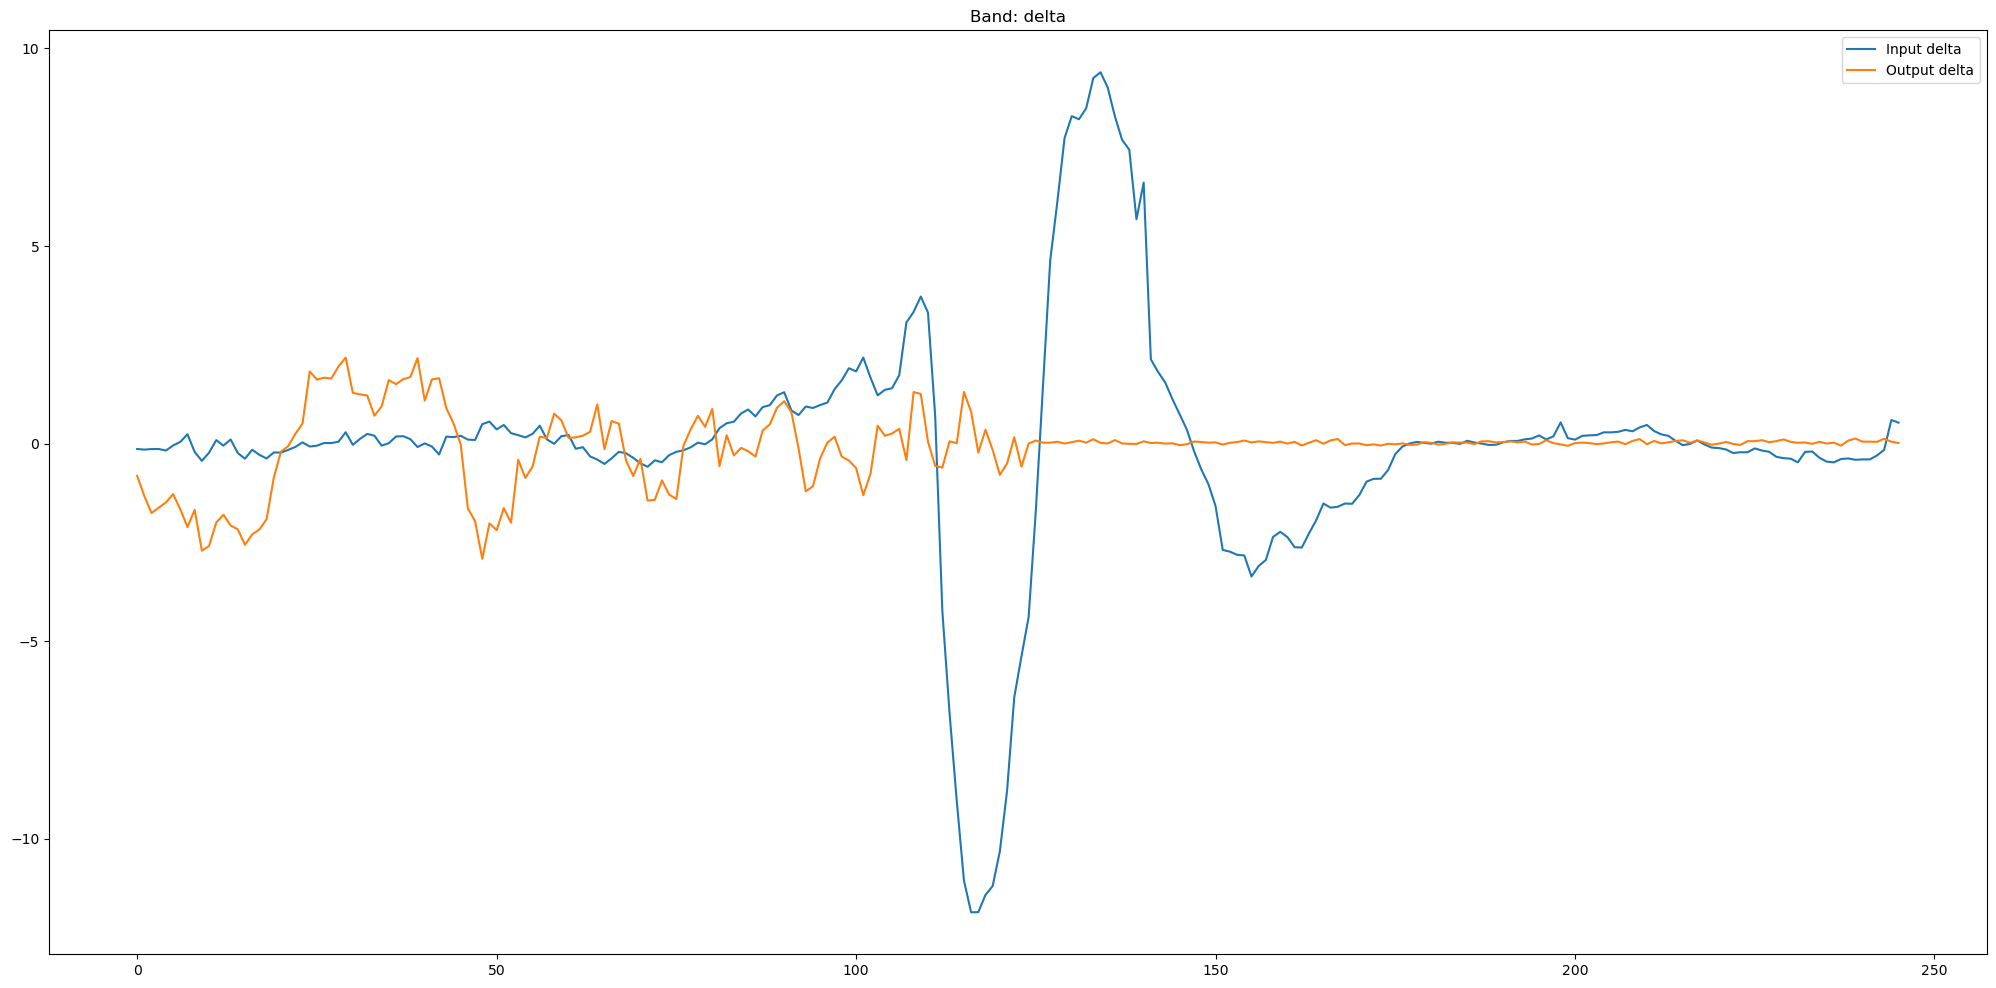

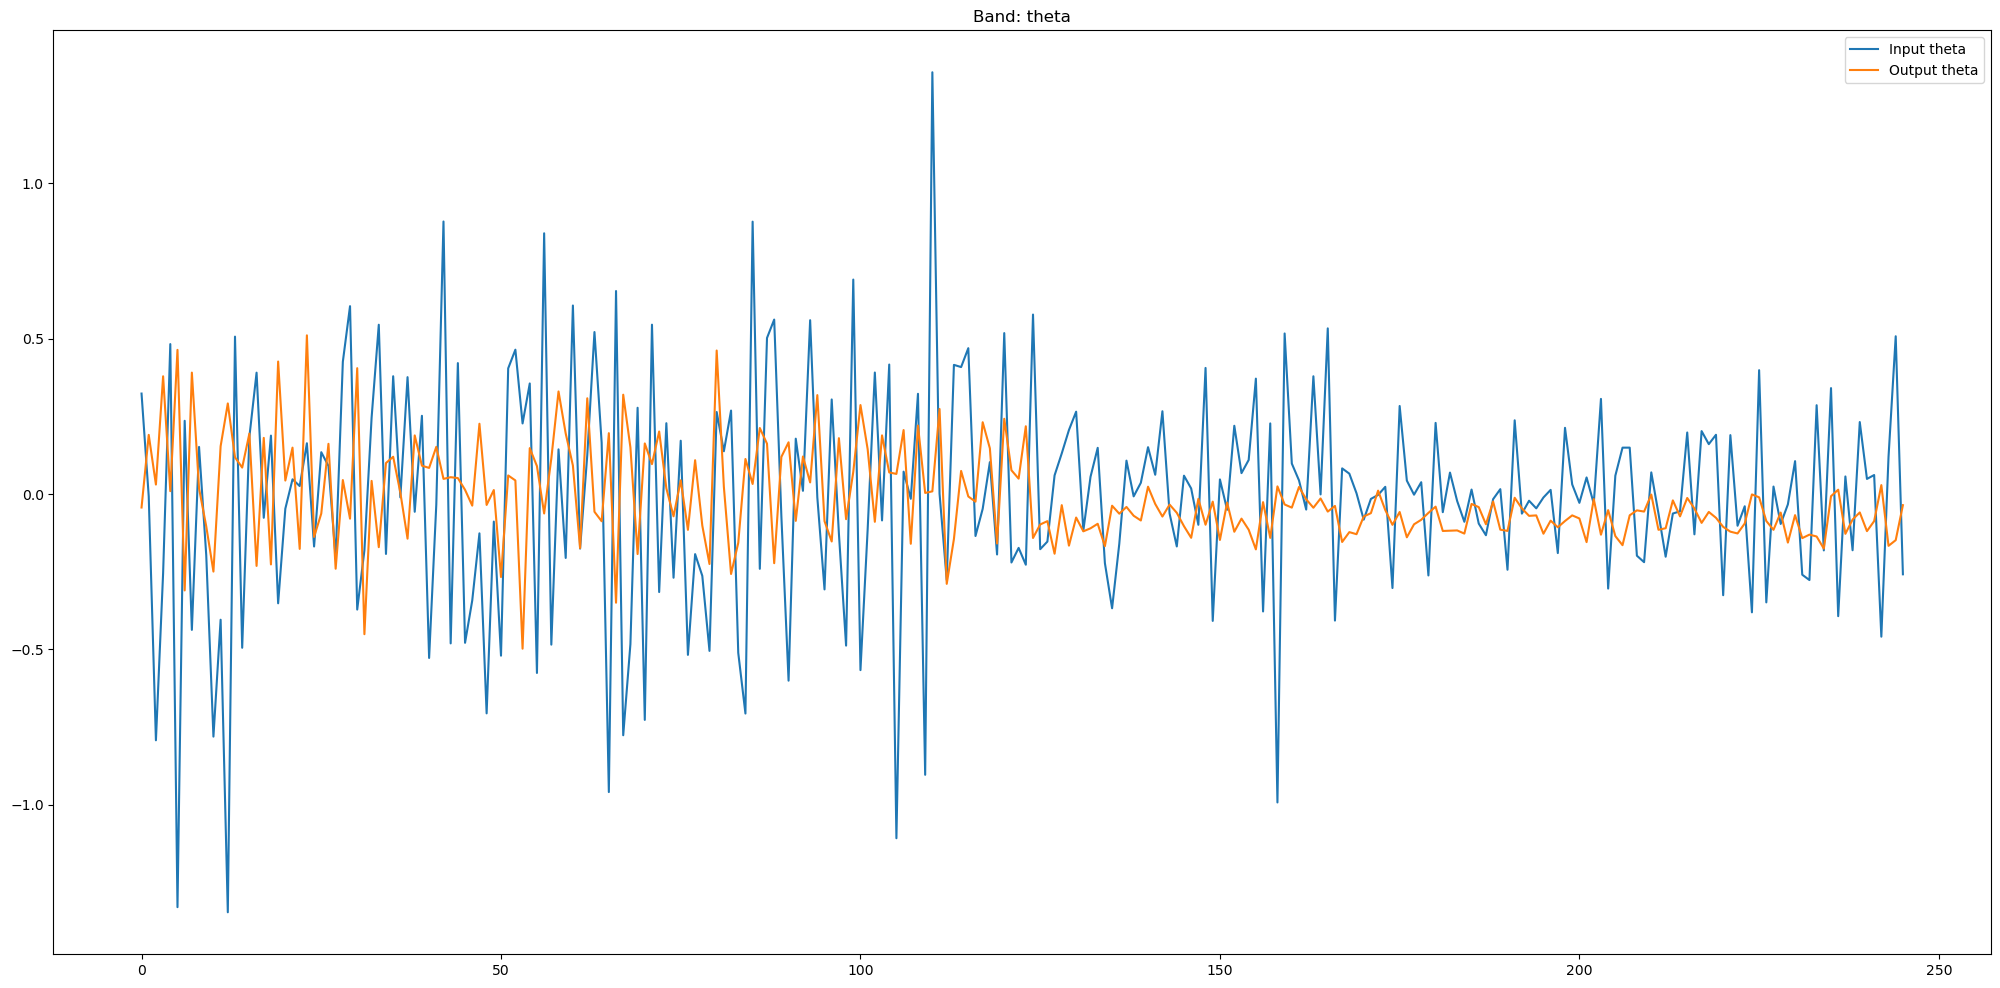

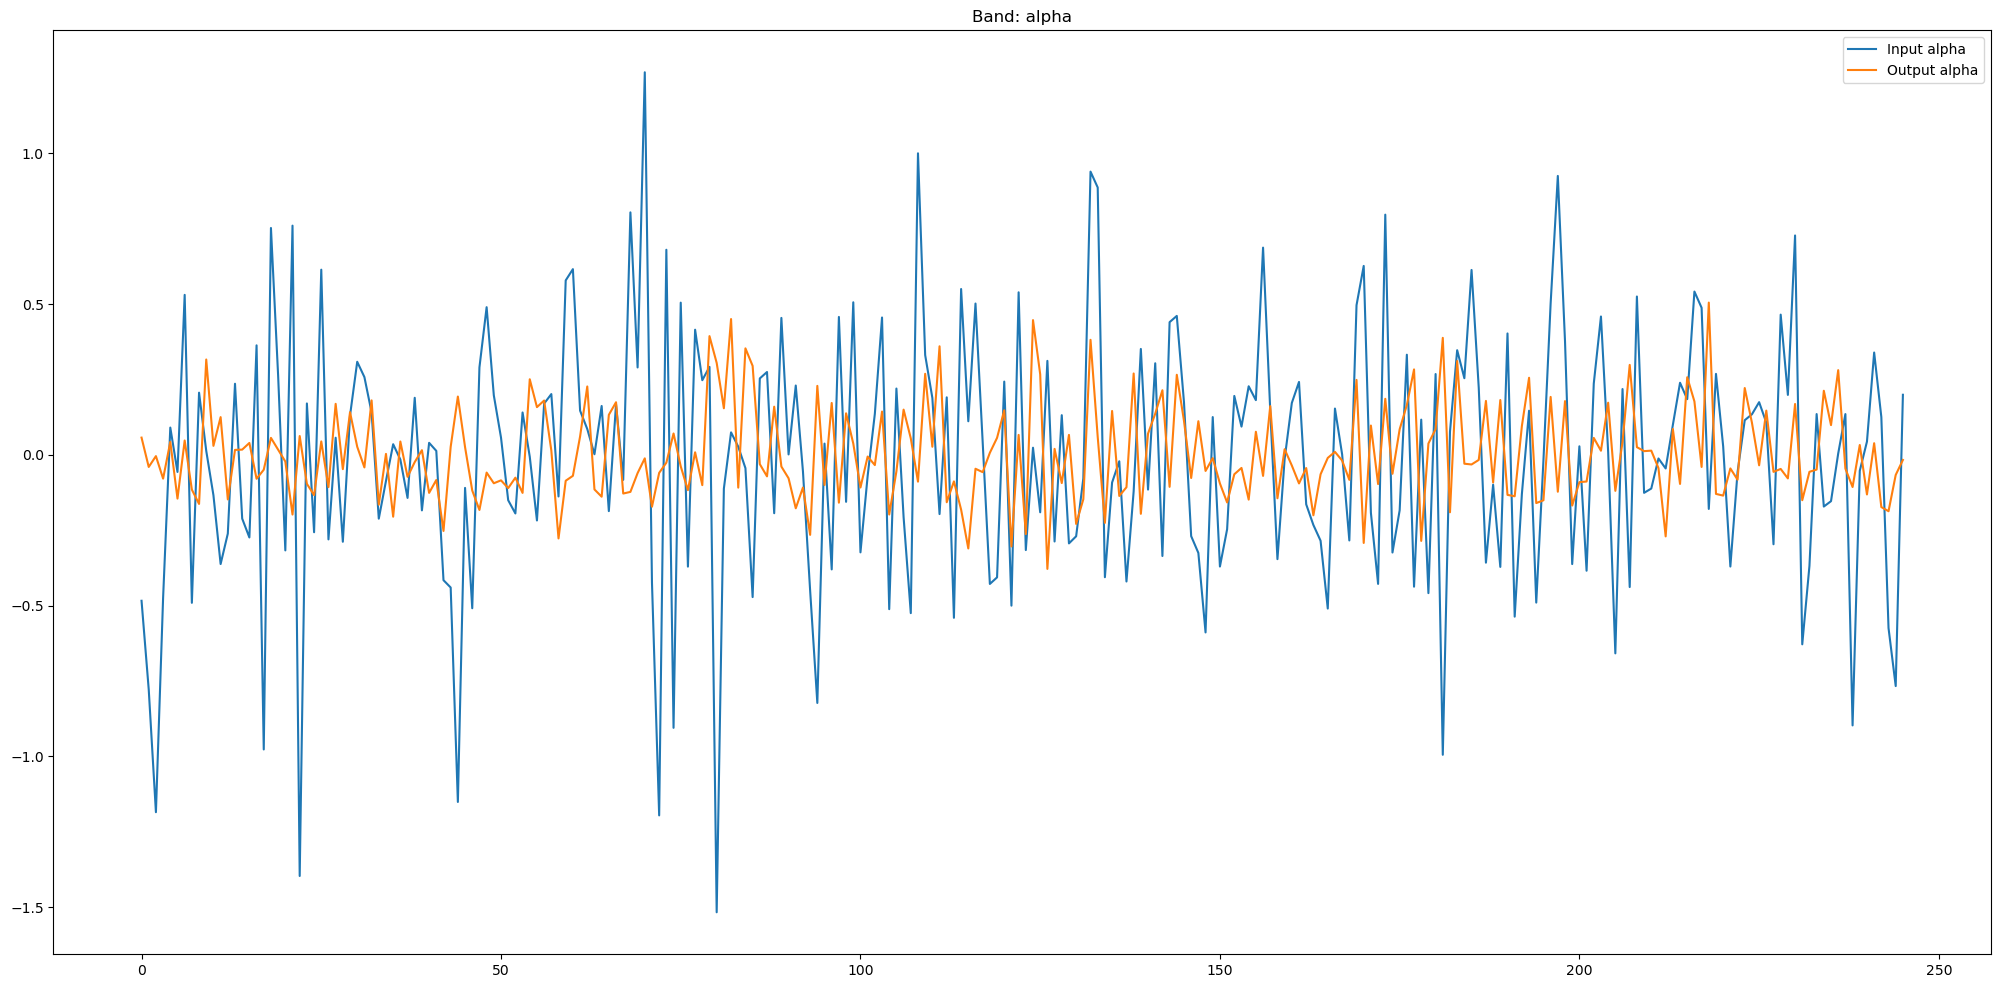

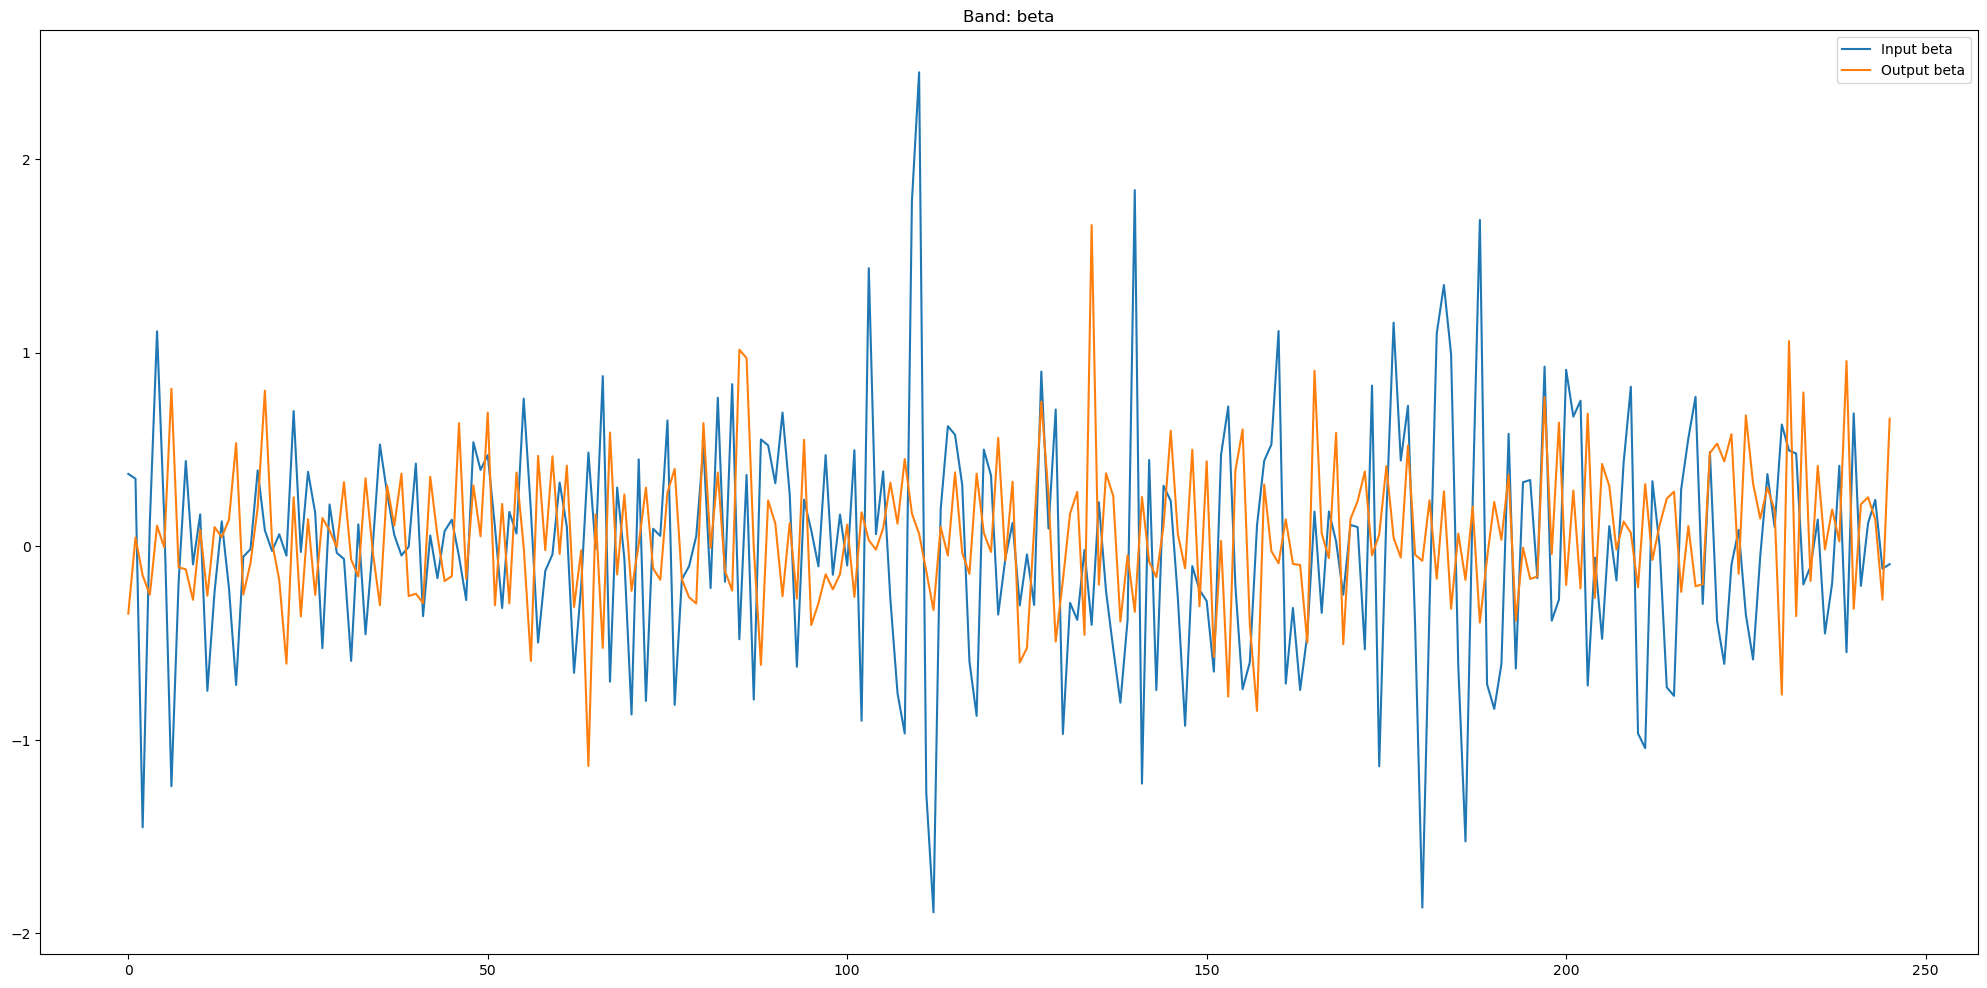

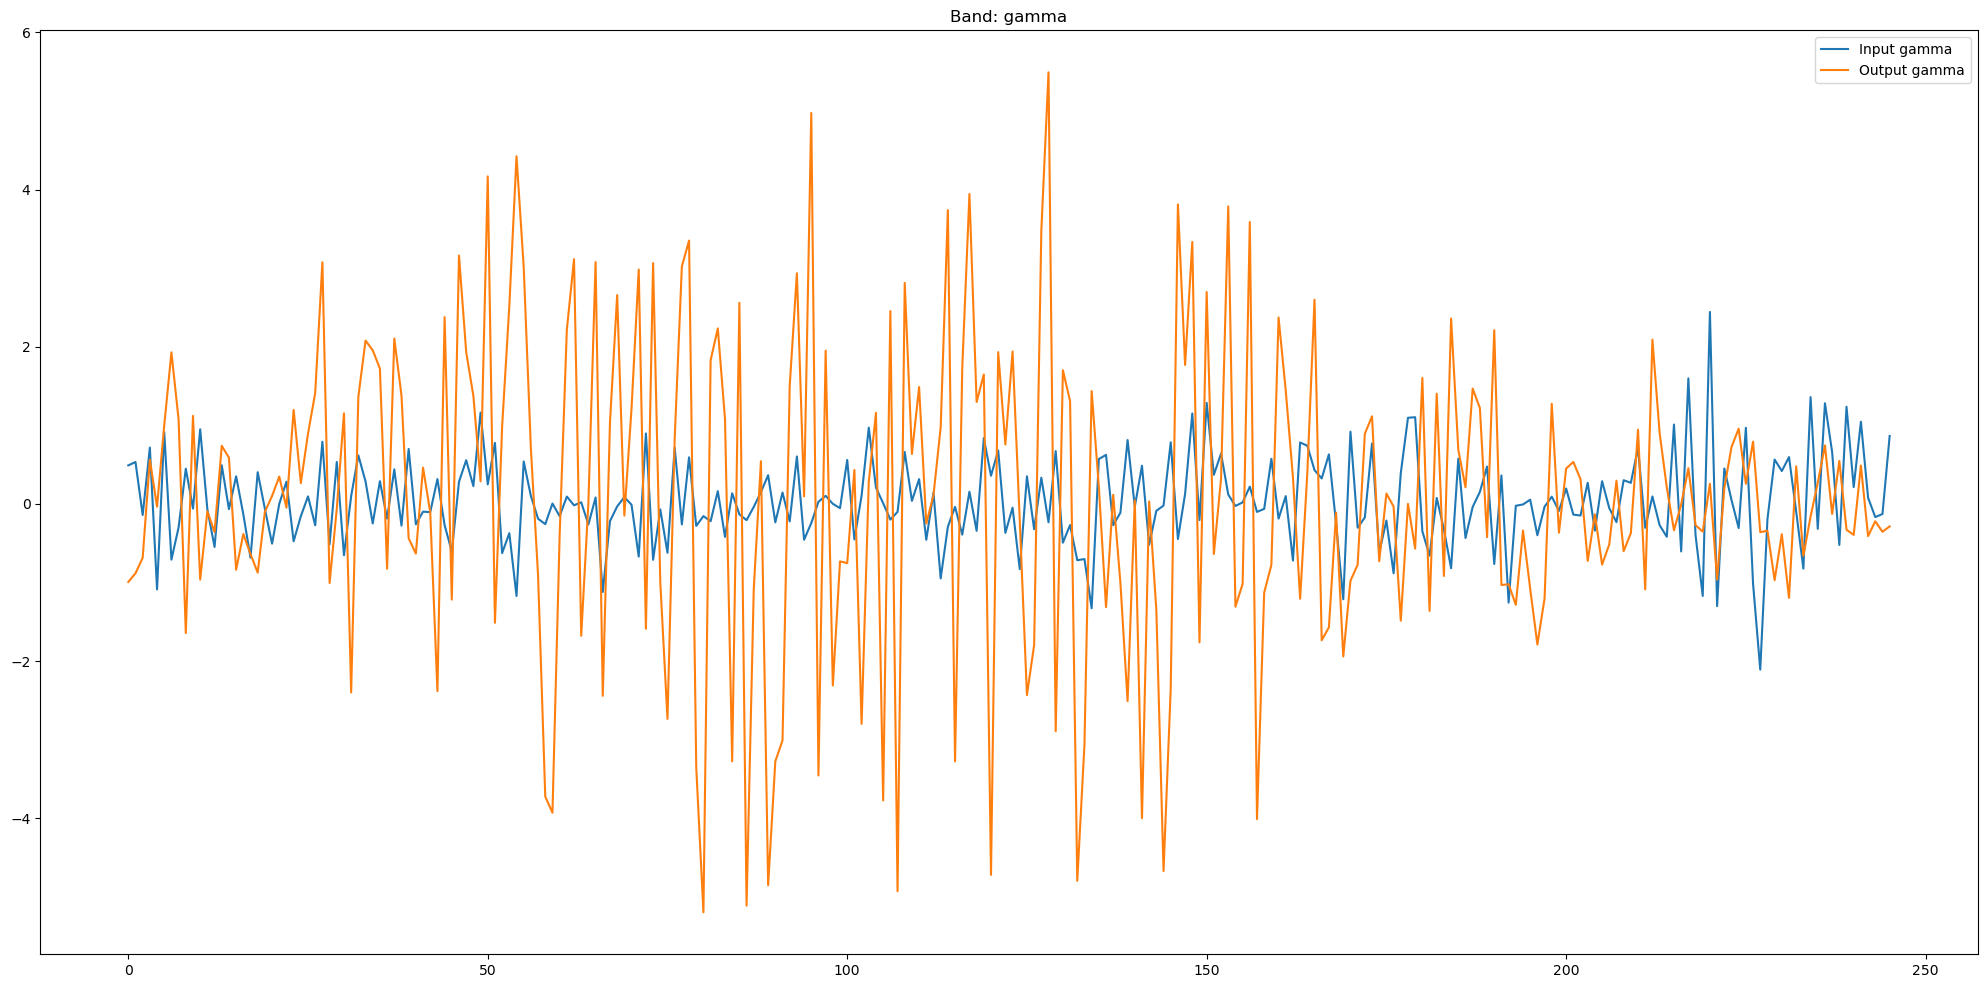

In [30]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][9,channel, :246].cpu().detach().numpy(), label=f"Input {band}")  
    plt.plot(outputs[band][1][9, channel, :246].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()